# Exploratory Data Analysis (EDA)
## OJS Real-Time Attack Detection Dataset

Comprehensive analysis of the ModSecurity dataset including data inspection, quality assessment, statistical analysis, and feature importance.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
import time
import warnings
import os

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Print settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Inspect Dataset

In [2]:
# Load dataset
data_path = '../data/dataset/modsec_raw_processed_updated.csv'
df = pd.read_csv(data_path)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

print("\n" + "-" * 80)
print("COLUMN INFORMATION")
print("-" * 80)
df.info()

DATASET OVERVIEW

Dataset Shape: (142705, 23)
Rows: 142,705, Columns: 23

--------------------------------------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142705 entries, 0 to 142704
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            0 non-null       float64
 1   source_ip            142705 non-null  object 
 2   method               142705 non-null  object 
 3   uri                  142705 non-null  object 
 4   status               142705 non-null  int64  
 5   bytes_sent           142705 non-null  int64  
 6   request_time         142705 non-null  float64
 7   user_agent           128982 non-null  object 
 8   user_agent_len       142705 non-null  int64  
 9   uri_len              142705 non-null  int64  
 10  severity         

In [3]:
print("\n" + "-" * 80)
print("FIRST FEW ROWS")
print("-" * 80)
df.head(10)


--------------------------------------------------------------------------------
FIRST FEW ROWS
--------------------------------------------------------------------------------


,timestamp,source_ip,method,uri,status,bytes_sent,request_time,user_agent,user_agent_len,uri_len,severity,severity_score,rule_id,matched_data,msg,is_blocked,label,has_sqli,has_xss,has_sqli_pattern,has_xss_pattern,has_suspicious_path,rule_count
0,NaN,0.0.0.0,GET,/wp-includesSimplePiegzdecodes.php,404,0,0.0,NaN,0,34,CRITICAL,4,933150,gzdecode,PHP Injection Attack: High-Risk PHP Function N...,False,0,0,0,0,0,0,0
1,NaN,0.0.0.0,GET,/d_3b1ec613/d_bd205cb5/gzdecodes.php,404,0,0.0,NaN,0,36,CRITICAL,4,933150,gzdecode,PHP Injection Attack: High-Risk PHP Function N...,False,0,0,0,0,0,0,0
2,NaN,0.0.0.0,GET,/d_58b7df65/d_4853cf40/d_a08340a6/d_d668184e/d...,301,0,0.0,Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like...,139,55,WARNING,2,920210,NaN,Multiple/Conflicting Connection Header Data Fo...,False,0,0,0,0,0,0,0
3,NaN,0.0.0.0,GET,/.git/config,404,0,0.0,NaN,0,12,CRITICAL,4,930130,/.git/,Restricted File Access Attempt,False,0,0,0,0,0,0,0
4,NaN,0.0.0.0,GET,/d_9161f094/d_74f0f511/semmelrock-alkalmazaste...,301,0,0.0,Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like...,139,66,WARNING,2,920210,NaN,Multiple/Conflicting Connection Header Data Fo...,False,0,0,0,0,0,0,0
5,NaN,0.0.0.0,GET,/d_022219ab/d_7a506bb6/d_eac5f762/d_620f83a6,304,0,0.0,Mozilla/5.0 (Windows NT 10.0; Win64; x64; tren...,202,44,CRITICAL,4,920450,NaN,HTTP header is restricted by policy (/accept-c...,False,0,0,0,0,0,0,0
6,NaN,0.0.0.0,GET,/robots.txt,403,0,0.0,NaN,0,11,CRITICAL,4,444444,DotBot,BAD BOT - Detected and Blocked.,True,1,0,0,0,0,0,0
7,NaN,0.0.0.0,GET,/robots.txt,403,0,0.0,NaN,0,11,CRITICAL,4,444444,DotBot,BAD BOT - Detected and Blocked.,True,1,0,0,0,0,0,0
8,NaN,0.0.0.0,GET,/wp-config.php,301,0,0.0,NaN,0,14,CRITICAL,4,930130,wp-config.php,Restricted File Access Attempt,False,0,0,0,0,0,0,0
9,NaN,0.0.0.0,GET,/wp-config.php,301,0,0.0,NaN,0,14,CRITICAL,4,930130,wp-config.php,Restricted File Access Attempt,False,0,0,0,0,0,0,0


In [4]:
print("\n" + "-" * 80)
print("DATA TYPES & COLUMNS LIST")
print("-" * 80)
print("\nData Types:")
print(df.dtypes)

print("\n" + "-" * 80)
print("COLUMN NAMES")
print("-" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


--------------------------------------------------------------------------------
DATA TYPES & COLUMNS LIST
--------------------------------------------------------------------------------

Data Types:
timestamp              float64
source_ip               object
method                  object
uri                     object
status                   int64
bytes_sent               int64
request_time           float64
user_agent              object
user_agent_len           int64
uri_len                  int64
severity                object
severity_score           int64
rule_id                  int64
matched_data            object
msg                     object
is_blocked                bool
label                    int64
has_sqli                 int64
has_xss                  int64
has_sqli_pattern         int64
has_xss_pattern          int64
has_suspicious_path      int64
rule_count               int64
dtype: object

----------------------------------------------------------------------

## 3. Data Quality Assessment

In [5]:
print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

# Missing values
print("\n" + "-" * 80)
print("MISSING VALUES")
print("-" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_df) == 0:
    print("✓ No missing values detected!")
else:
    print(missing_df.to_string(index=False))

# Duplicates
print("\n" + "-" * 80)
print("DUPLICATE ROWS")
print("-" * 80)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
print(f"Duplicate percentage: {(duplicates/len(df)*100):.2f}%")

# Data consistency
print("\n" + "-" * 80)
print("DATA COMPLETENESS")
print("-" * 80)
total_cells = df.shape[0] * df.shape[1]
null_cells = df.isnull().sum().sum()
completeness = ((total_cells - null_cells) / total_cells) * 100
print(f"Total cells: {total_cells:,}")
print(f"Null cells: {null_cells:,}")
print(f"Completeness: {completeness:.2f}%")

DATA QUALITY ASSESSMENT

--------------------------------------------------------------------------------
MISSING VALUES
--------------------------------------------------------------------------------
      Column  Missing Count  Missing %
   timestamp         142705 100.000000
matched_data          44368  31.090712
  user_agent          13723   9.616341
    severity             21   0.014716
         msg              3   0.002102

--------------------------------------------------------------------------------
DUPLICATE ROWS
--------------------------------------------------------------------------------
Total duplicate rows: 110502
Duplicate percentage: 77.43%

--------------------------------------------------------------------------------
DATA COMPLETENESS
--------------------------------------------------------------------------------
Total cells: 3,282,215
Null cells: 200,820
Completeness: 93.88%


## 4. Statistical Summary and Distribution Analysis

In [6]:
print("=" * 80)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 80)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nNumeric columns: {len(numeric_cols)}")
print(df[numeric_cols].describe().T)

STATISTICAL SUMMARY - NUMERICAL FEATURES

Numeric columns: 15
                        count           mean            std       min  \
timestamp                 0.0            NaN            NaN       NaN   
status               142705.0     395.061154      48.260993     301.0   
bytes_sent           142705.0       0.000000       0.000000       0.0   
request_time         142705.0       0.000000       0.000000       0.0   
user_agent_len       142705.0      88.409628      42.775497       0.0   
uri_len              142705.0      22.827567      84.764371       1.0   
severity_score       142705.0       3.633867       0.894410       0.0   
rule_id              142705.0  765627.605452  227179.069076  200002.0   
label                142705.0       0.333282       0.471388       0.0   
has_sqli             142705.0       0.009138       0.095154       0.0   
has_xss              142705.0       0.000799       0.028253       0.0   
has_sqli_pattern     142705.0       0.003279       0.057173   

In [7]:
print("\n" + "-" * 80)
print("CATEGORICAL FEATURES DISTRIBUTION")
print("-" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


--------------------------------------------------------------------------------
CATEGORICAL FEATURES DISTRIBUTION
--------------------------------------------------------------------------------

source_ip:
source_ip
0.0.0.0    142705
Name: count, dtype: int64

method:
method
GET         127567
POST         14484
HEAD           499
PROPFIND        71
PUT             47
OPTIONS         12
DELETE          12
CONNECT          6
PATCH            6
ROAJ             1
Name: count, dtype: int64

uri:
uri
/robots.txt      17489
/xmlrpc.php       9966
/                 8254
/.env             4517
/.git/config      3917
/api/.env         1420
/.git/HEAD        1231
/d_43826a23        930
/admin/.env        918
/backend/.env      906
Name: count, dtype: int64

user_agent:
user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36                                                                                           36269
Moz


TARGET VARIABLE (label) DISTRIBUTION

Value counts:
label
0    95144
1    47561
Name: count, dtype: int64

Percentage:
label
0    66.671805
1    33.328195
Name: proportion, dtype: float64


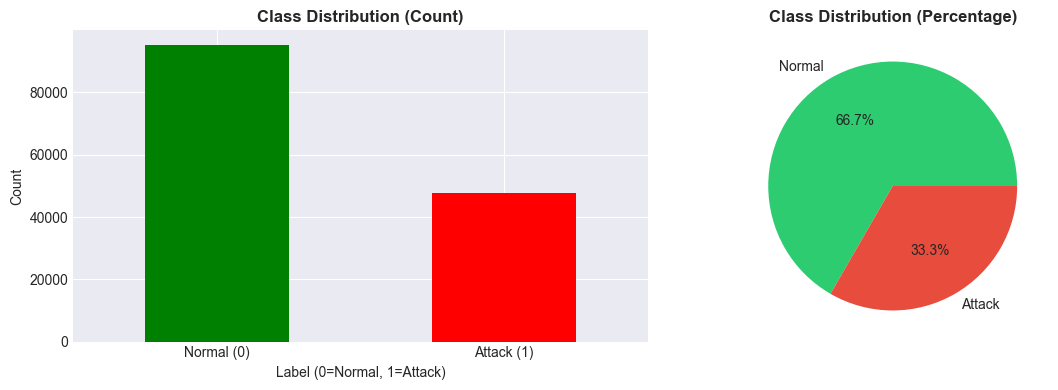

In [8]:
# Target variable distribution
if 'label' in df.columns:
    print("\n" + "=" * 80)
    print("TARGET VARIABLE (label) DISTRIBUTION")
    print("=" * 80)
    print("\nValue counts:")
    print(df['label'].value_counts().sort_index())
    print("\nPercentage:")
    print(df['label'].value_counts(normalize=True).sort_index() * 100)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot
    df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
    axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Label (0=Normal, 1=Attack)')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'], rotation=0)
    
    # Pie chart
    labels = ['Normal', 'Attack']
    colors = ['#2ecc71', '#e74c3c']
    df['label'].value_counts().plot(kind='pie', ax=axes[1], labels=labels, colors=colors, autopct='%1.1f%%')
    axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

## 5. Feature Importance Analysis

⏱️ **Note:** This section uses Random Forest which may take 30-60 seconds to complete depending on dataset size.

FEATURE IMPORTANCE ANALYSIS

Features used for importance: 15

--------------------------------------------------------------------------------
METHOD 1: Mutual Information Score
--------------------------------------------------------------------------------
                Feature  MI Score
8                 label  0.647098
7               rule_id  0.643303
4        user_agent_len  0.513299
1                status  0.432697
5               uri_len  0.264572
13  has_suspicious_path  0.127059
6        severity_score  0.085124
9              has_sqli  0.003707
10              has_xss  0.002156
11     has_sqli_pattern  0.002128
3          request_time  0.001487
0             timestamp  0.000687
12      has_xss_pattern  0.000377
2            bytes_sent  0.000000
14           rule_count  0.000000


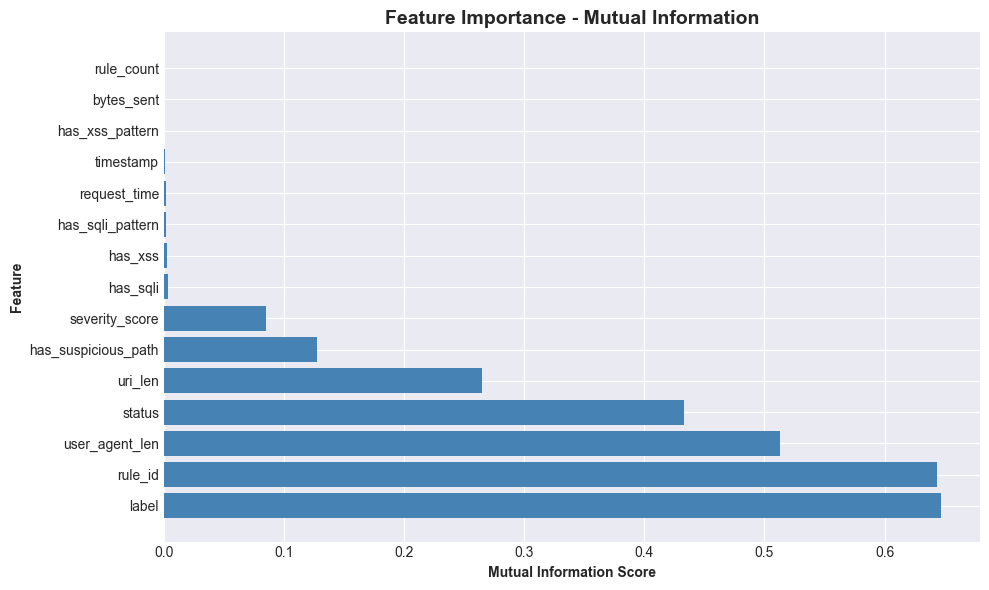

In [9]:
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Prepare data for feature importance
if 'label' in df.columns:
    # Select only numeric features for analysis
    X = df[numeric_cols]
    y = df['label']
    
    # Handle any remaining NaN values
    X = X.fillna(0)
    
    print(f"\nFeatures used for importance: {len(numeric_cols)}")
    
    # Method 1: Mutual Information
    print("\n" + "-" * 80)
    print("METHOD 1: Mutual Information Score")
    print("-" * 80)
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X.columns,
        'MI Score': mi_scores
    }).sort_values('MI Score', ascending=False)
    print(mi_df)
    
    # Visualize MI scores
    plt.figure(figsize=(10, 6))
    plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')
    plt.xlabel('Mutual Information Score', fontweight='bold')
    plt.ylabel('Feature', fontweight='bold')
    plt.title('Feature Importance - Mutual Information', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


--------------------------------------------------------------------------------
METHOD 2: Random Forest Feature Importance (⏳ Processing...)
--------------------------------------------------------------------------------
✓ Random Forest training completed in 1.41 seconds
                Feature  Importance
8                 label    0.392184
7               rule_id    0.350921
4        user_agent_len    0.112952
1                status    0.094522
13  has_suspicious_path    0.024445
5               uri_len    0.014631
6        severity_score    0.009411
9              has_sqli    0.000669
11     has_sqli_pattern    0.000136
12      has_xss_pattern    0.000111
10              has_xss    0.000019
3          request_time    0.000000
2            bytes_sent    0.000000
0             timestamp    0.000000
14           rule_count    0.000000


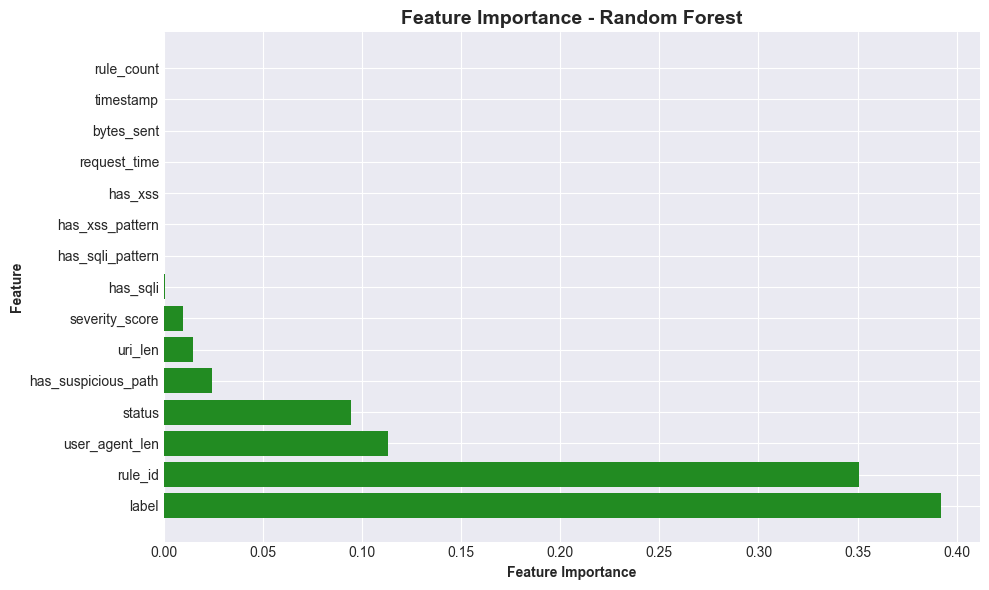

In [10]:
    # Method 2: Random Forest Feature Importance (ini yang lama)
    print("\n" + "-" * 80)
    print("METHOD 2: Random Forest Feature Importance (⏳ Processing...)")
    print("-" * 80)
    
    start_time = time.time()
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X, y)
    elapsed = time.time() - start_time
    
    rf_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(f"✓ Random Forest training completed in {elapsed:.2f} seconds")
    print(rf_importance_df)
    
    # Visualize RF importance
    plt.figure(figsize=(10, 6))
    plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='forestgreen')
    plt.xlabel('Feature Importance', fontweight='bold')
    plt.ylabel('Feature', fontweight='bold')
    plt.title('Feature Importance - Random Forest', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


--------------------------------------------------------------------------------
METHOD 3: Correlation with Target Variable
--------------------------------------------------------------------------------
                Feature  Correlation
0                 label     1.000000
1               rule_id     0.999564
2   has_suspicious_path     0.408947
3        user_agent_len     0.363373
4        severity_score     0.289426
5                status     0.101687
6              has_sqli     0.067896
7      has_sqli_pattern     0.040556
8       has_xss_pattern     0.021595
9               has_xss     0.019991
10              uri_len     0.003276
11            timestamp          NaN
12           bytes_sent          NaN
13         request_time          NaN
14           rule_count          NaN


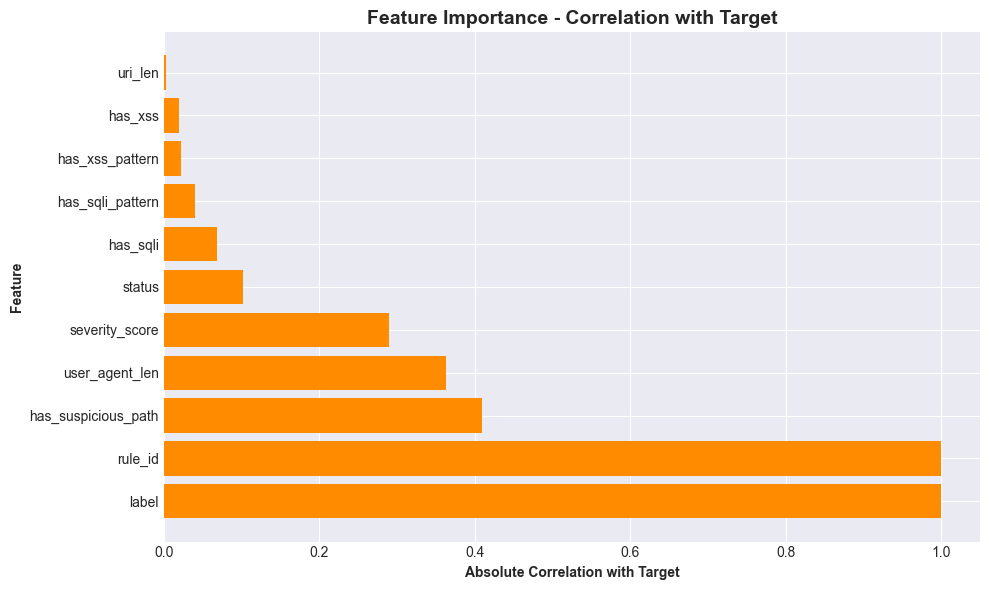

In [11]:
    # Method 3: Correlation with target
    print("\n" + "-" * 80)
    print("METHOD 3: Correlation with Target Variable")
    print("-" * 80)
    
    correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
    corr_df = pd.DataFrame({
        'Feature': correlation_with_target.index,
        'Correlation': correlation_with_target.values
    })
    print(corr_df)
    
    # Visualize correlation
    plt.figure(figsize=(10, 6))
    plt.barh(corr_df['Feature'], corr_df['Correlation'], color='darkorange')
    plt.xlabel('Absolute Correlation with Target', fontweight='bold')
    plt.ylabel('Feature', fontweight='bold')
    plt.title('Feature Importance - Correlation with Target', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Correlation and Relationship Analysis

CORRELATION ANALYSIS

Correlation Matrix:
                     timestamp    status  bytes_sent  request_time  \
timestamp                  NaN       NaN         NaN           NaN   
status                     NaN  1.000000         NaN           NaN   
bytes_sent                 NaN       NaN         NaN           NaN   
request_time               NaN       NaN         NaN           NaN   
user_agent_len             NaN -0.174972         NaN           NaN   
uri_len                    NaN -0.048027         NaN           NaN   
severity_score             NaN -0.272084         NaN           NaN   
rule_id                    NaN -0.100053         NaN           NaN   
label                      NaN  0.101687         NaN           NaN   
has_sqli                   NaN -0.014742         NaN           NaN   
has_xss                    NaN  0.001002         NaN           NaN   
has_sqli_pattern           NaN -0.026589         NaN           NaN   
has_xss_pattern            NaN  0.003573        

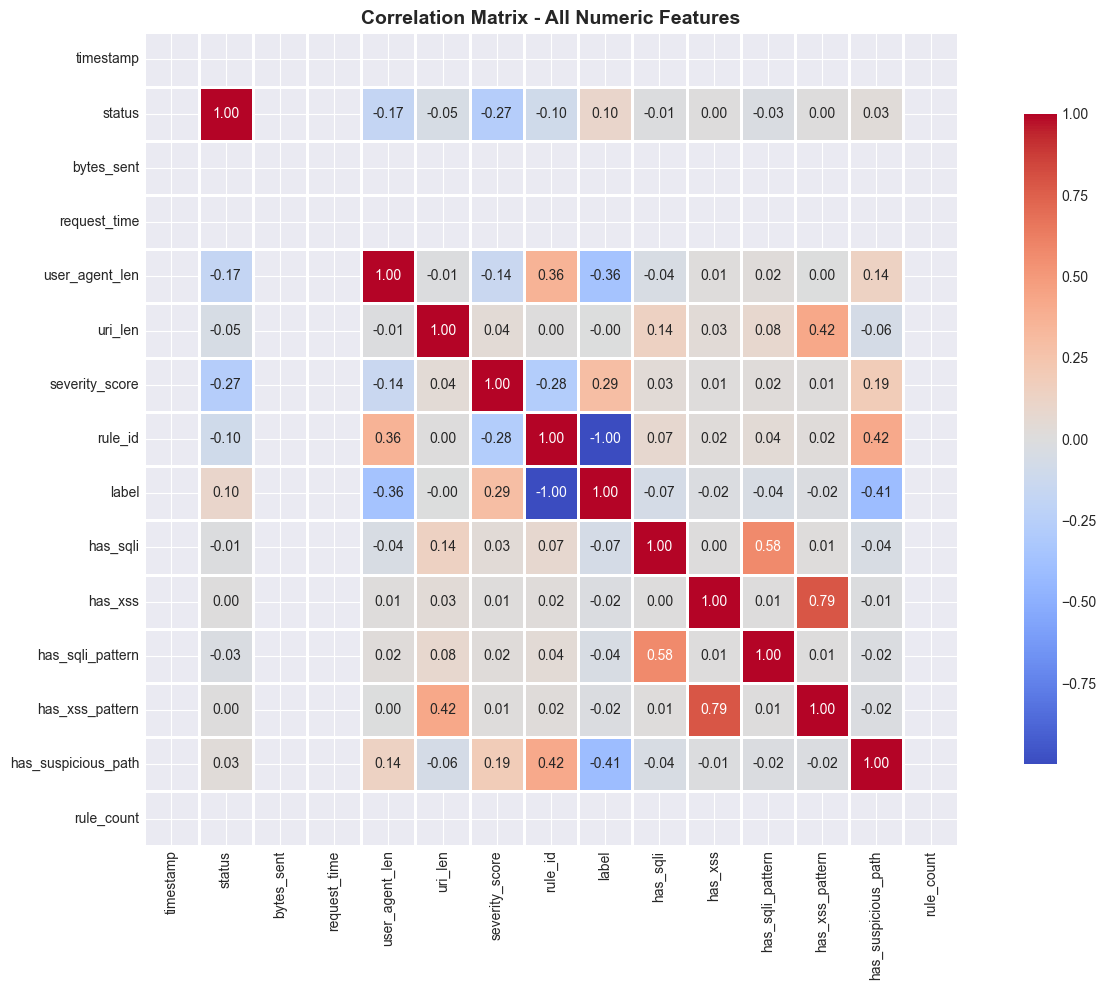

In [12]:
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Visualize correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Detect multicollinearity
print("\n" + "-" * 80)
print("MULTICOLLINEARITY CHECK (Correlation > 0.9)")
print("-" * 80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(high_corr_df)
else:
    print("✓ No highly correlated feature pairs found (>0.9)")


--------------------------------------------------------------------------------
MULTICOLLINEARITY CHECK (Correlation > 0.9)
--------------------------------------------------------------------------------
  Feature 1 Feature 2  Correlation
0   rule_id     label    -0.999564


## 7. Identify Missing Values and Outliers

In [14]:
print("=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)

# Detect outliers using IQR method
outlier_info = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df)) * 100
    
    if outliers > 0:
        outlier_info.append({
            'Feature': col,
            'Outliers': outliers,
            'Outlier %': outlier_pct,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        })

if outlier_info:
    outlier_df = pd.DataFrame(outlier_info).sort_values('Outlier %', ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("✓ No outliers detected!")

OUTLIER DETECTION (IQR Method)
         Feature  Outliers  Outlier %  Lower Bound  Upper Bound
          status     33793  23.680320        401.5        405.5
         uri_len     22555  15.805333         -5.5         38.5
  severity_score     21333  14.949021          4.0          4.0
  user_agent_len     16938  11.869241         15.0        175.0
        has_sqli      1304   0.913773          0.0          0.0
has_sqli_pattern       468   0.327949          0.0          0.0
 has_xss_pattern       133   0.093199          0.0          0.0
         has_xss       114   0.079885          0.0          0.0


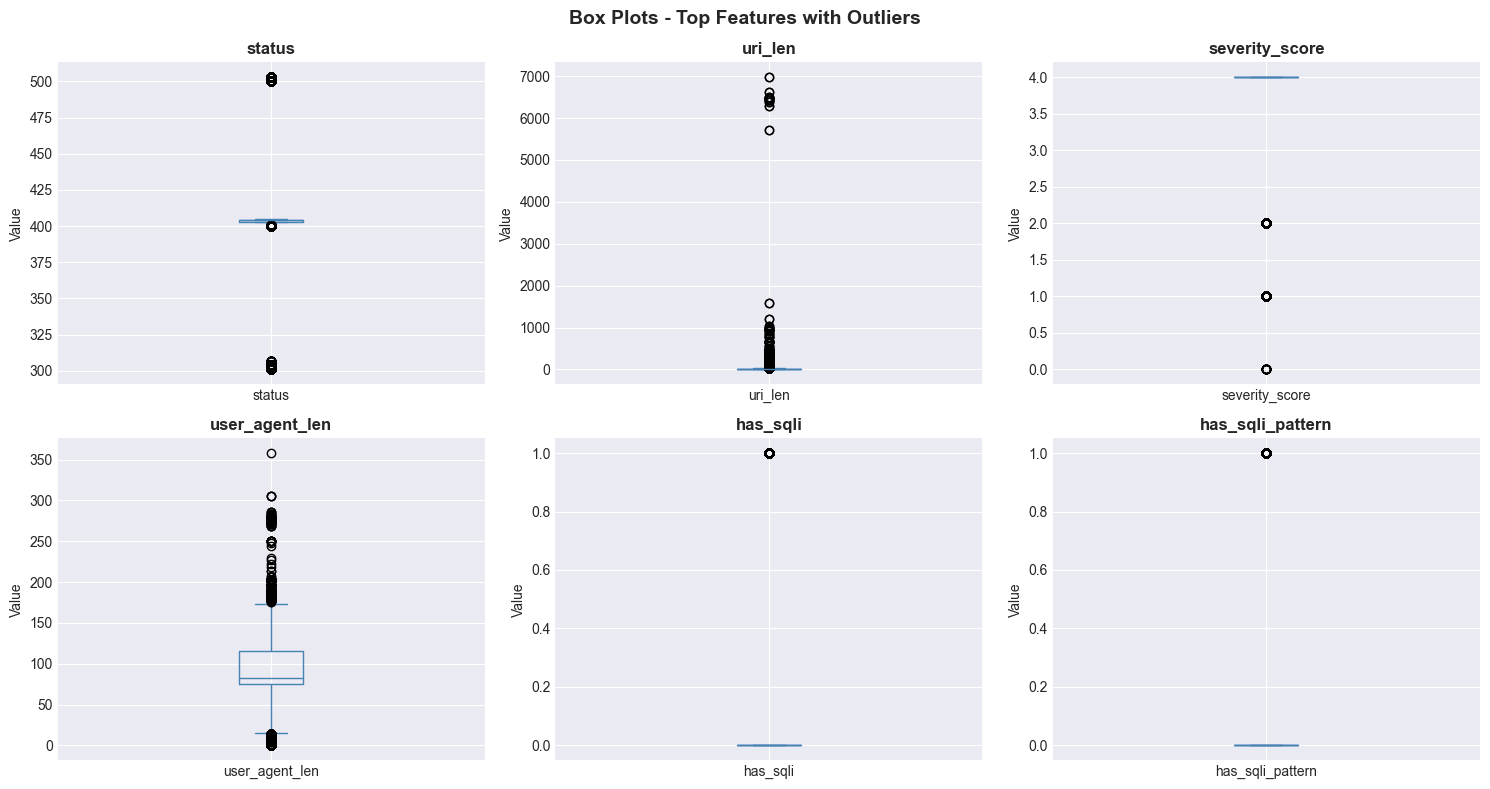

In [15]:
# Visualize outliers
if outlier_info and len(outlier_info) > 0:
    top_outlier_features = [item['Feature'] for item in sorted(outlier_info, 
                                                                 key=lambda x: x['Outlier %'], 
                                                                 reverse=True)[:6]]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    
    for idx, col in enumerate(top_outlier_features):
        df[col].plot(kind='box', ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Value')
    
    plt.suptitle('Box Plots - Top Features with Outliers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Visualization of Key Features

VISUALIZATION OF KEY FEATURES


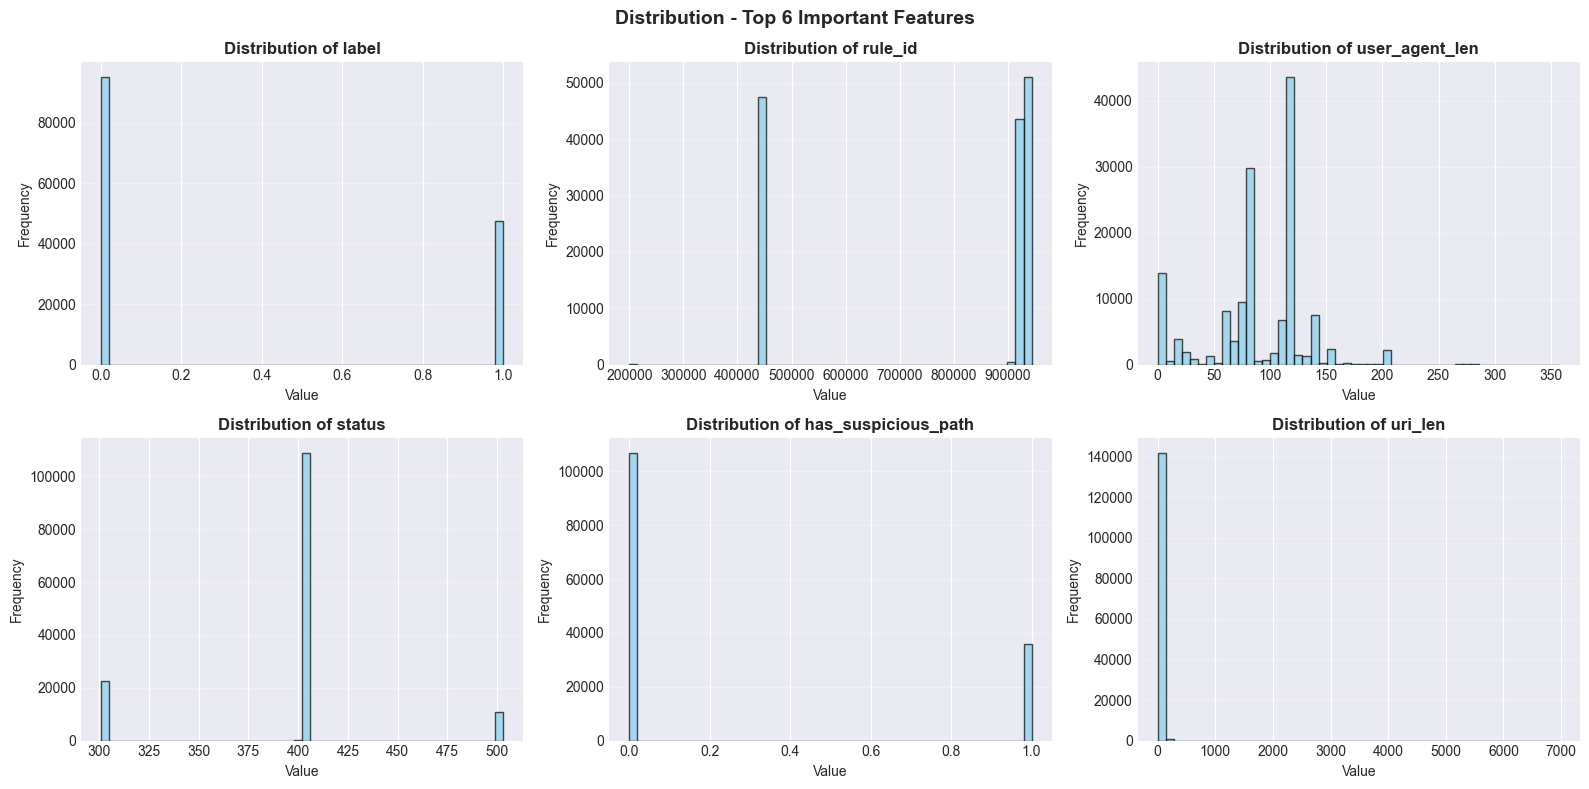

In [16]:
print("=" * 80)
print("VISUALIZATION OF KEY FEATURES")
print("=" * 80)

# Top features from feature importance
top_features = rf_importance_df.head(6)['Feature'].tolist()

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].hist(df[feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution - Top 6 Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

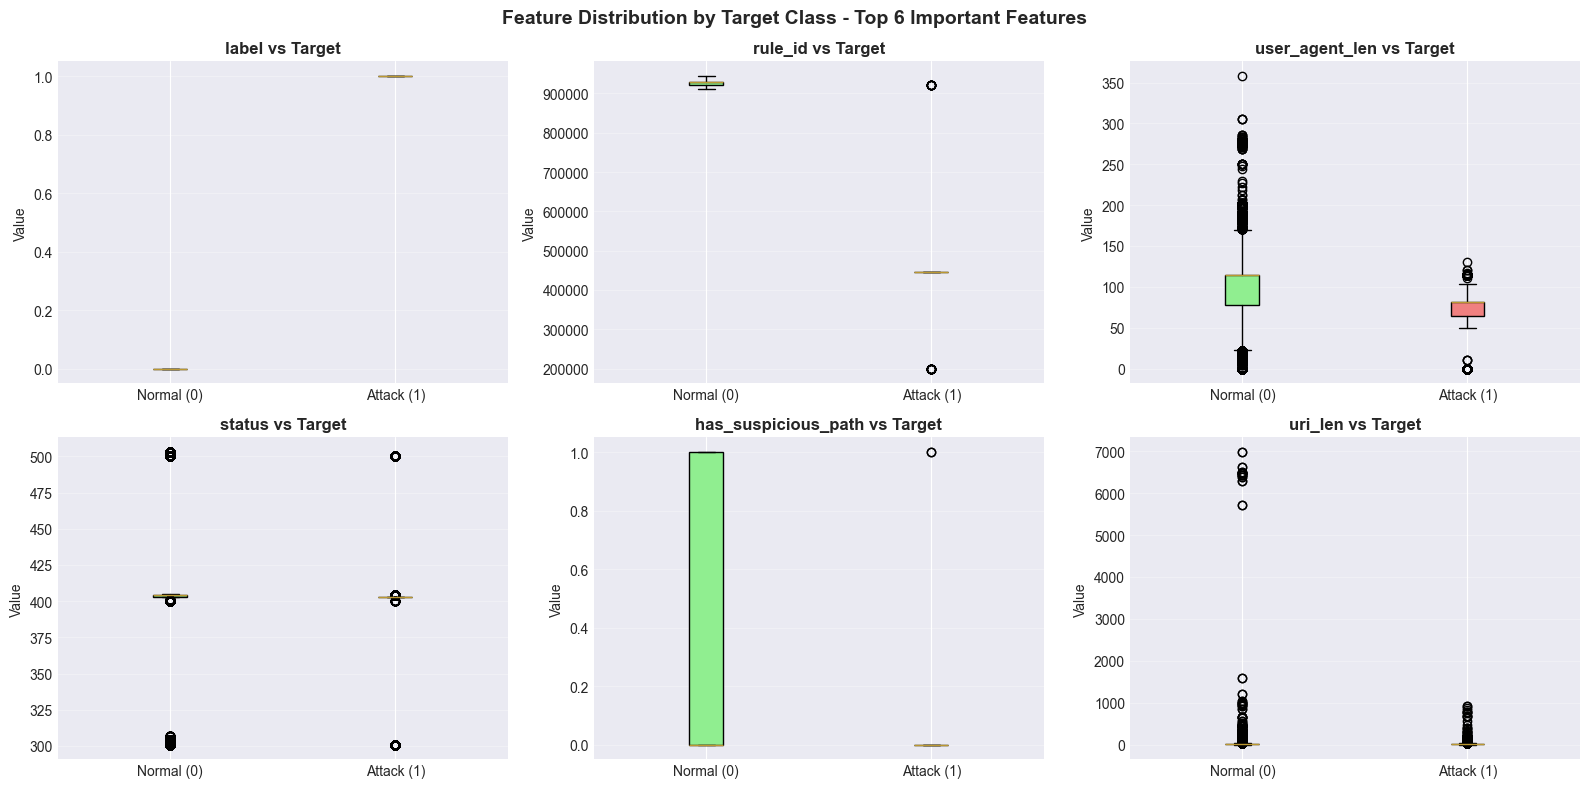

In [17]:
# Feature vs Target relationship
if 'label' in df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        # Box plot for each class
        data_by_label = [df[df['label'] == 0][feature], df[df['label'] == 1][feature]]
        bp = axes[idx].boxplot(data_by_label, labels=['Normal (0)', 'Attack (1)'], patch_artist=True)
        
        # Color the boxes
        colors = ['lightgreen', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        axes[idx].set_title(f'{feature} vs Target', fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Feature Distribution by Target Class - Top 6 Important Features', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


--------------------------------------------------------------------------------
BINARY FEATURES (Boolean/Flag Features)
--------------------------------------------------------------------------------


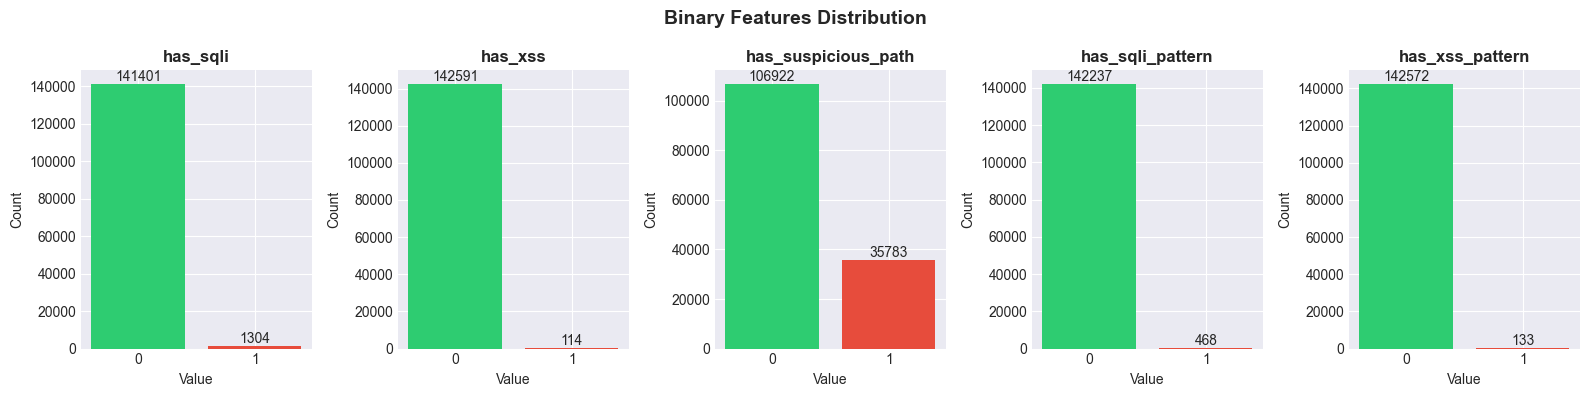


has_sqli:
  0 (Negative): 141,401 (99.09%)
  1 (Positive): 1,304 (0.91%)

has_xss:
  0 (Negative): 142,591 (99.92%)
  1 (Positive): 114 (0.08%)

has_suspicious_path:
  0 (Negative): 106,922 (74.93%)
  1 (Positive): 35,783 (25.07%)

has_sqli_pattern:
  0 (Negative): 142,237 (99.67%)
  1 (Positive): 468 (0.33%)

has_xss_pattern:
  0 (Negative): 142,572 (99.91%)
  1 (Positive): 133 (0.09%)


In [18]:
# Binary features analysis
print("\n" + "-" * 80)
print("BINARY FEATURES (Boolean/Flag Features)")
print("-" * 80)

binary_features = ['has_sqli', 'has_xss', 'has_suspicious_path', 'has_path_traversal', 
                   'has_command_injection', 'has_sqli_pattern', 'has_xss_pattern']
binary_features = [f for f in binary_features if f in df.columns]

if binary_features:
    fig, axes = plt.subplots(1, len(binary_features), figsize=(16, 4))
    if len(binary_features) == 1:
        axes = [axes]
    
    for idx, feature in enumerate(binary_features):
        if feature in df.columns:
            counts = df[feature].value_counts()
            colors = ['#2ecc71', '#e74c3c']
            axes[idx].bar(counts.index, counts.values, color=colors[:len(counts)])
            axes[idx].set_title(f'{feature}', fontweight='bold')
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Count')
            axes[idx].set_xticks([0, 1])
            
            # Add value labels on bars
            for i, v in enumerate(counts.values):
                axes[idx].text(counts.index[i], v, str(v), ha='center', va='bottom')
    
    plt.suptitle('Binary Features Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    for feature in binary_features:
        if feature in df.columns:
            counts = df[feature].value_counts()
            print(f"\n{feature}:")
            print(f"  0 (Negative): {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.2f}%)")
            print(f"  1 (Positive): {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.2f}%)")

## 9. Summary - Key Insights

In [19]:
# Summary statistics for key features
print("\n" + "=" * 80)
print("SUMMARY - KEY INSIGHTS")
print("=" * 80)

if 'label' in df.columns:
    print(f"\n✓ Dataset Size: {len(df):,} records")
    print(f"✓ Normal Instances: {(df['label']==0).sum():,} ({(df['label']==0).sum()/len(df)*100:.2f}%)")
    print(f"✓ Attack Instances: {(df['label']==1).sum():,} ({(df['label']==1).sum()/len(df)*100:.2f}%)")
    print(f"✓ Data Balance: {'Balanced' if abs((df['label']==0).sum()-(df['label']==1).sum()) < len(df)*0.1 else 'Imbalanced'}")

print(f"\n✓ Total Features: {len(df.columns)}")
print(f"✓ Numeric Features: {len(numeric_cols)}")
print(f"✓ Categorical Features: {len(categorical_cols)}")

print(f"\n✓ Top 3 Most Important Features (Random Forest):")
for idx, row in rf_importance_df.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n✓ Data Quality: {completeness:.2f}% complete")
print(f"✓ Duplicates: {duplicates} rows")
print(f"✓ Missing Values: {'None' if len(missing_df) == 0 else f'{len(missing_df)} columns with missing data'}")

print("\n" + "=" * 80)
print("EDA COMPLETE!")
print("=" * 80)


SUMMARY - KEY INSIGHTS

✓ Dataset Size: 142,705 records
✓ Normal Instances: 95,144 (66.67%)
✓ Attack Instances: 47,561 (33.33%)
✓ Data Balance: Imbalanced

✓ Total Features: 23
✓ Numeric Features: 15
✓ Categorical Features: 7

✓ Top 3 Most Important Features (Random Forest):
  9. label: 0.3922
  8. rule_id: 0.3509
  5. user_agent_len: 0.1130

✓ Data Quality: 93.88% complete
✓ Duplicates: 110502 rows
✓ Missing Values: 5 columns with missing data

EDA COMPLETE!


In [20]:
# Summary statistics for key features
print("\n" + "=" * 80)
print("SUMMARY - KEY INSIGHTS")
print("=" * 80)

if 'label' in df.columns:
    print(f"\n✓ Dataset Size: {len(df):,} records")
    print(f"✓ Normal Instances: {(df['label']==0).sum():,} ({(df['label']==0).sum()/len(df)*100:.2f}%)")
    print(f"✓ Attack Instances: {(df['label']==1).sum():,} ({(df['label']==1).sum()/len(df)*100:.2f}%)")
    print(f"✓ Data Balance: {'Balanced' if abs((df['label']==0).sum()-(df['label']==1).sum()) < len(df)*0.1 else 'Imbalanced'}")

print(f"\n✓ Total Features: {len(df.columns)}")
print(f"✓ Numeric Features: {len(numeric_cols)}")
print(f"✓ Categorical Features: {len(categorical_cols)}")

print(f"\n✓ Top 3 Most Important Features (Random Forest):")
for idx, row in rf_importance_df.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n✓ Data Quality: {completeness:.2f}% complete")
print(f"✓ Duplicates: {duplicates} rows")
print(f"✓ Missing Values: {'None' if len(missing_df) == 0 else f'{len(missing_df)} columns with missing data'}")

print("\n" + "=" * 80)
print("EDA COMPLETE!")
print("=" * 80)


SUMMARY - KEY INSIGHTS

✓ Dataset Size: 142,705 records
✓ Normal Instances: 95,144 (66.67%)
✓ Attack Instances: 47,561 (33.33%)
✓ Data Balance: Imbalanced

✓ Total Features: 23
✓ Numeric Features: 15
✓ Categorical Features: 7

✓ Top 3 Most Important Features (Random Forest):
  9. label: 0.3922
  8. rule_id: 0.3509
  5. user_agent_len: 0.1130

✓ Data Quality: 93.88% complete
✓ Duplicates: 110502 rows
✓ Missing Values: 5 columns with missing data

EDA COMPLETE!


## 9. Summary - Key Insights


--------------------------------------------------------------------------------
BINARY FEATURES (Boolean/Flag Features)
--------------------------------------------------------------------------------


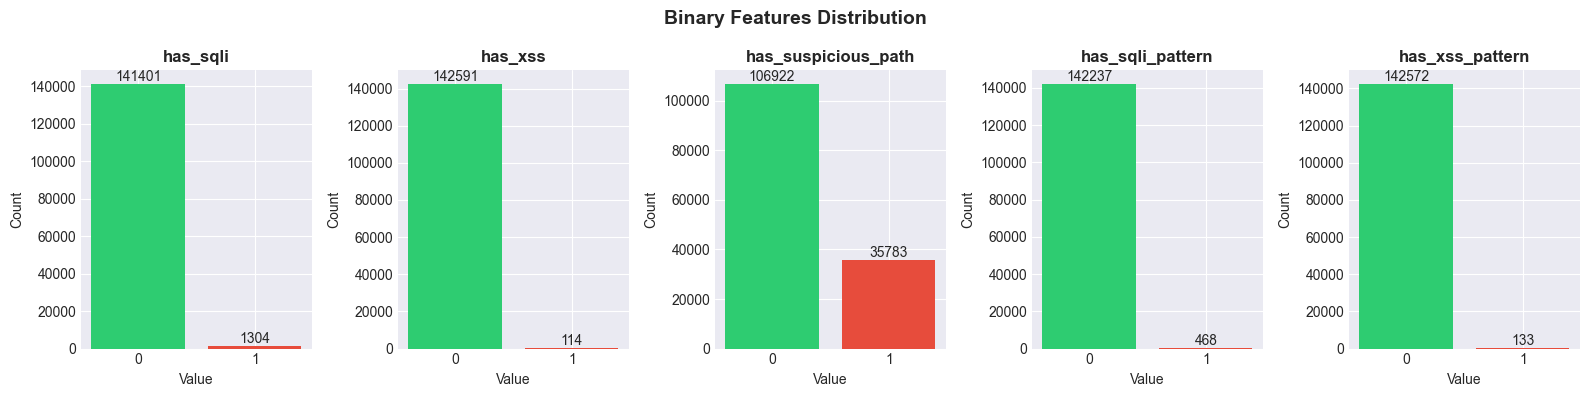


has_sqli:
  0 (Negative): 141,401 (99.09%)
  1 (Positive): 1,304 (0.91%)

has_xss:
  0 (Negative): 142,591 (99.92%)
  1 (Positive): 114 (0.08%)

has_suspicious_path:
  0 (Negative): 106,922 (74.93%)
  1 (Positive): 35,783 (25.07%)

has_sqli_pattern:
  0 (Negative): 142,237 (99.67%)
  1 (Positive): 468 (0.33%)

has_xss_pattern:
  0 (Negative): 142,572 (99.91%)
  1 (Positive): 133 (0.09%)


In [21]:
# Binary features analysis
print("\n" + "-" * 80)
print("BINARY FEATURES (Boolean/Flag Features)")
print("-" * 80)

binary_features = ['has_sqli', 'has_xss', 'has_suspicious_path', 'has_path_traversal', 
                   'has_command_injection', 'has_sqli_pattern', 'has_xss_pattern']
binary_features = [f for f in binary_features if f in df.columns]

if binary_features:
    fig, axes = plt.subplots(1, len(binary_features), figsize=(16, 4))
    if len(binary_features) == 1:
        axes = [axes]
    
    for idx, feature in enumerate(binary_features):
        if feature in df.columns:
            counts = df[feature].value_counts()
            colors = ['#2ecc71', '#e74c3c']
            axes[idx].bar(counts.index, counts.values, color=colors[:len(counts)])
            axes[idx].set_title(f'{feature}', fontweight='bold')
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Count')
            axes[idx].set_xticks([0, 1])
            
            # Add value labels on bars
            for i, v in enumerate(counts.values):
                axes[idx].text(counts.index[i], v, str(v), ha='center', va='bottom')
    
    plt.suptitle('Binary Features Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    for feature in binary_features:
        if feature in df.columns:
            counts = df[feature].value_counts()
            print(f"\n{feature}:")
            print(f"  0 (Negative): {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.2f}%)")
            print(f"  1 (Positive): {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.2f}%)")

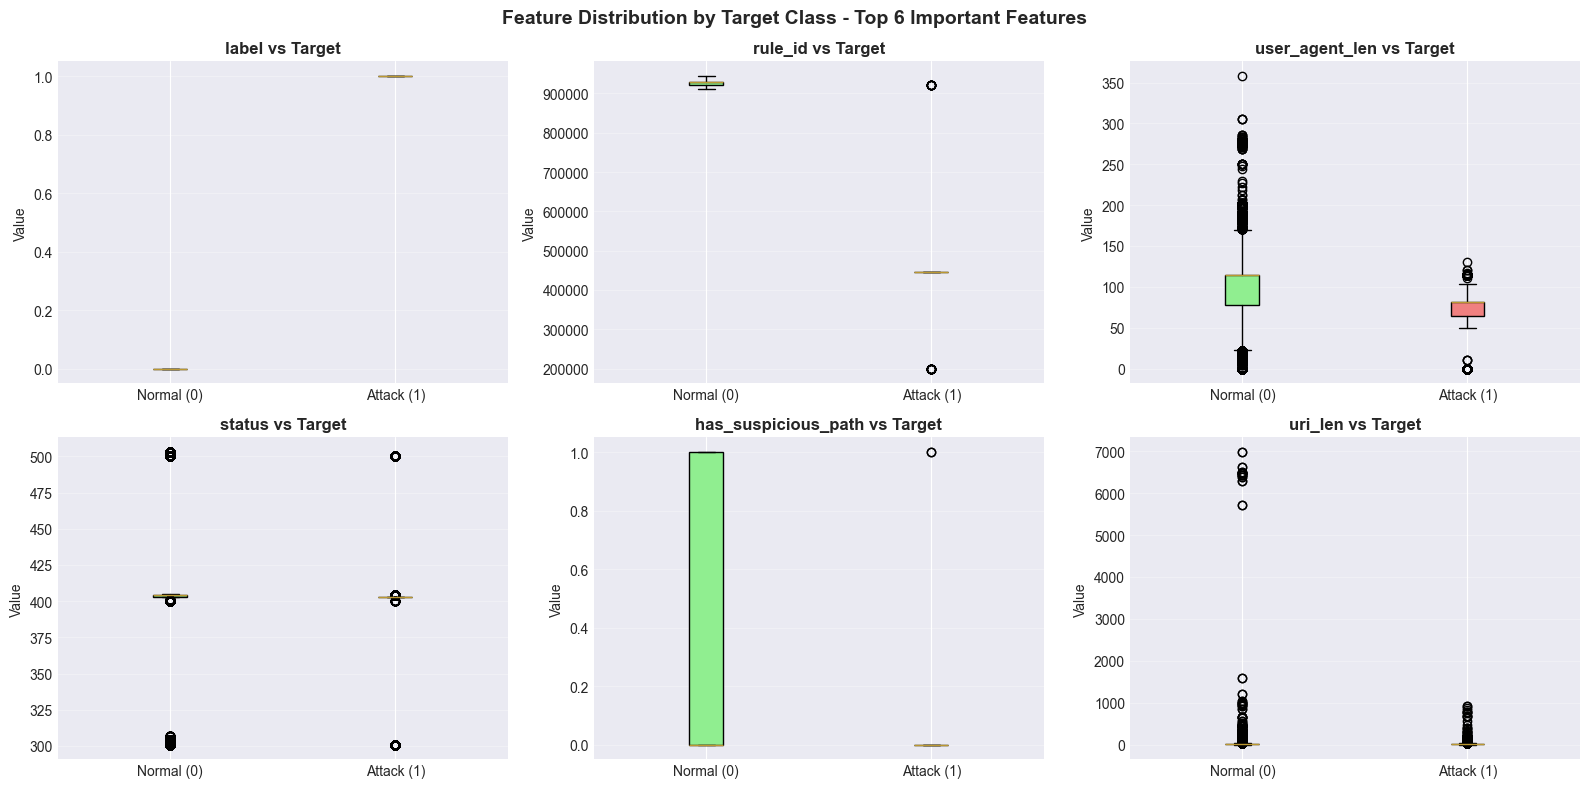

In [22]:
# Feature vs Target relationship
if 'label' in df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        # Box plot for each class
        data_by_label = [df[df['label'] == 0][feature], df[df['label'] == 1][feature]]
        bp = axes[idx].boxplot(data_by_label, labels=['Normal (0)', 'Attack (1)'], patch_artist=True)
        
        # Color the boxes
        colors = ['lightgreen', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        axes[idx].set_title(f'{feature} vs Target', fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Feature Distribution by Target Class - Top 6 Important Features', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

VISUALIZATION OF KEY FEATURES


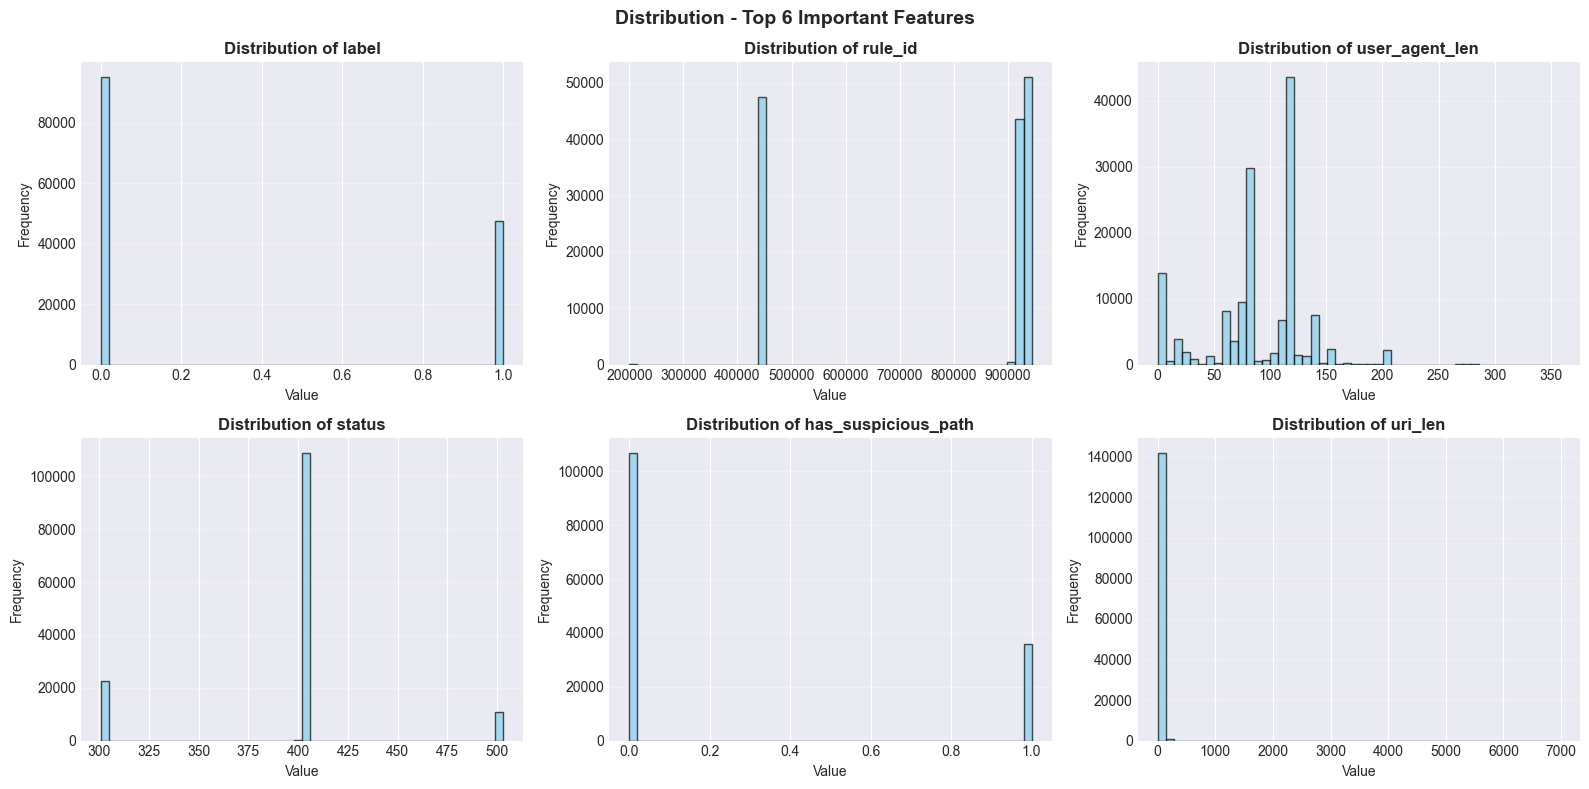

In [23]:
print("=" * 80)
print("VISUALIZATION OF KEY FEATURES")
print("=" * 80)

# Top features from feature importance
top_features = rf_importance_df.head(6)['Feature'].tolist()

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].hist(df[feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution - Top 6 Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualization of Key Features

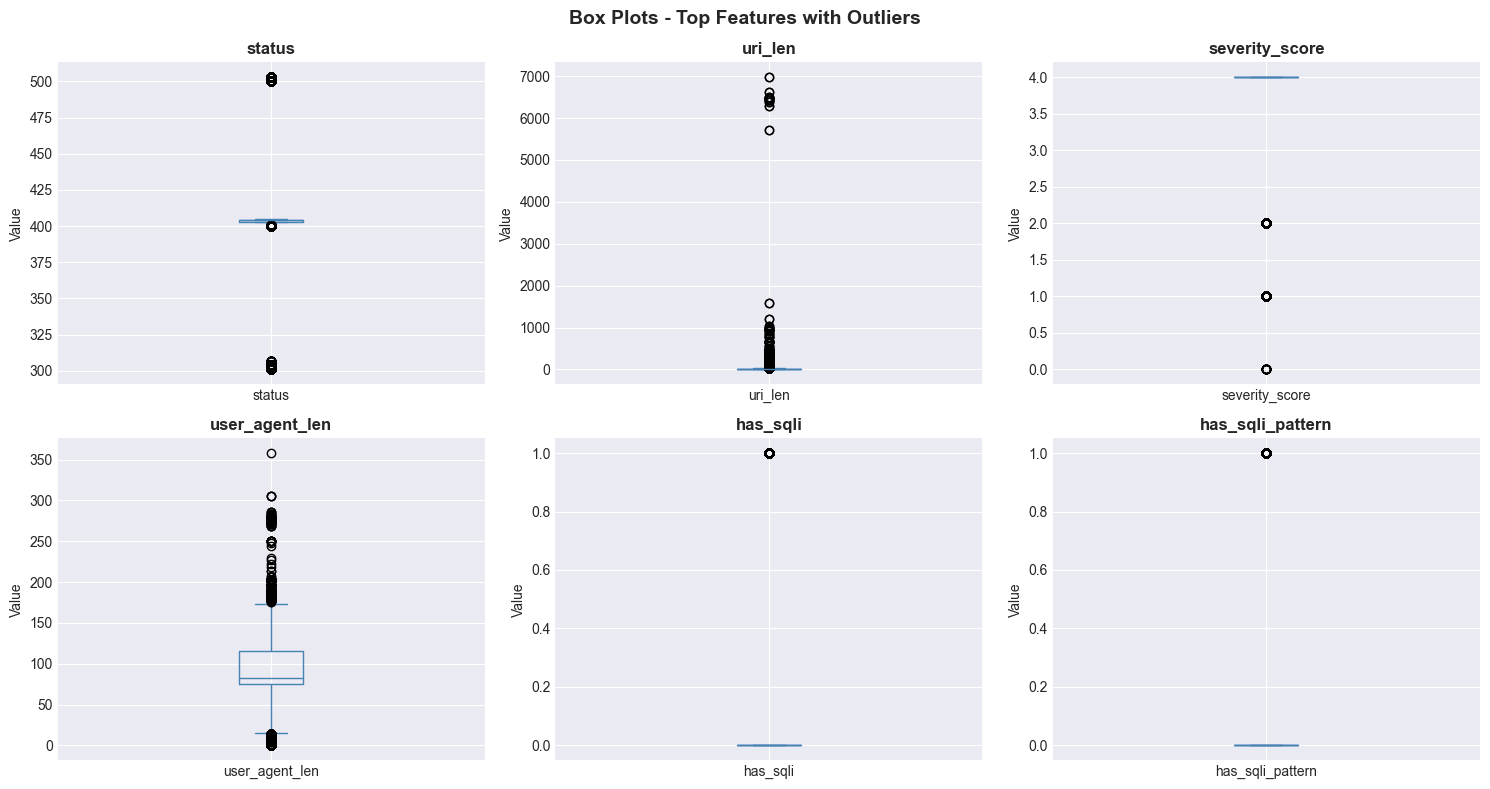

In [24]:
# Visualize outliers
if outlier_info and len(outlier_info) > 0:
    top_outlier_features = [item['Feature'] for item in sorted(outlier_info, 
                                                                 key=lambda x: x['Outlier %'], 
                                                                 reverse=True)[:6]]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    
    for idx, col in enumerate(top_outlier_features):
        df[col].plot(kind='box', ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Value')
    
    plt.suptitle('Box Plots - Top Features with Outliers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [25]:
print("=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)

# Detect outliers using IQR method
outlier_info = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df)) * 100
    
    if outliers > 0:
        outlier_info.append({
            'Feature': col,
            'Outliers': outliers,
            'Outlier %': outlier_pct,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        })

if outlier_info:
    outlier_df = pd.DataFrame(outlier_info).sort_values('Outlier %', ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("✓ No outliers detected!")

OUTLIER DETECTION (IQR Method)
         Feature  Outliers  Outlier %  Lower Bound  Upper Bound
          status     33793  23.680320        401.5        405.5
         uri_len     22555  15.805333         -5.5         38.5
  severity_score     21333  14.949021          4.0          4.0
  user_agent_len     16938  11.869241         15.0        175.0
        has_sqli      1304   0.913773          0.0          0.0
has_sqli_pattern       468   0.327949          0.0          0.0
 has_xss_pattern       133   0.093199          0.0          0.0
         has_xss       114   0.079885          0.0          0.0


## 7. Identify Missing Values and Outliers

In [26]:
# Detect multicollinearity
print("\n" + "-" * 80)
print("MULTICOLLINEARITY CHECK (Correlation > 0.9)")
print("-" * 80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(high_corr_df)
else:
    print("✓ No highly correlated feature pairs found (>0.9)")


--------------------------------------------------------------------------------
MULTICOLLINEARITY CHECK (Correlation > 0.9)
--------------------------------------------------------------------------------
  Feature 1 Feature 2  Correlation
0   rule_id     label    -0.999564


CORRELATION ANALYSIS

Correlation Matrix:
                     timestamp    status  bytes_sent  request_time  \
timestamp                  NaN       NaN         NaN           NaN   
status                     NaN  1.000000         NaN           NaN   
bytes_sent                 NaN       NaN         NaN           NaN   
request_time               NaN       NaN         NaN           NaN   
user_agent_len             NaN -0.174972         NaN           NaN   
uri_len                    NaN -0.048027         NaN           NaN   
severity_score             NaN -0.272084         NaN           NaN   
rule_id                    NaN -0.100053         NaN           NaN   
label                      NaN  0.101687         NaN           NaN   
has_sqli                   NaN -0.014742         NaN           NaN   
has_xss                    NaN  0.001002         NaN           NaN   
has_sqli_pattern           NaN -0.026589         NaN           NaN   
has_xss_pattern            NaN  0.003573        

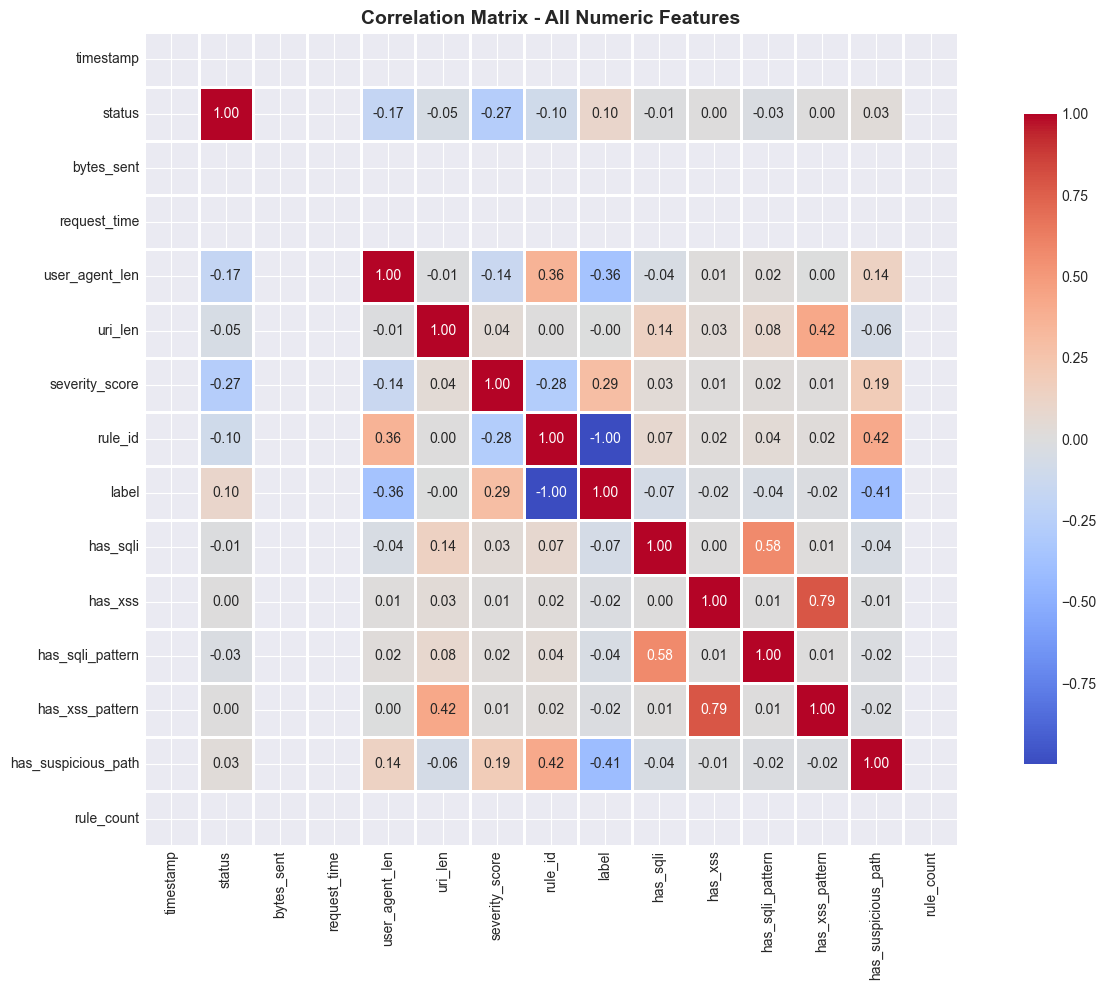

In [27]:
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Visualize correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Correlation and Relationship Analysis


--------------------------------------------------------------------------------
METHOD 3: Correlation with Target Variable
--------------------------------------------------------------------------------
                Feature  Correlation
0                 label     1.000000
1               rule_id     0.999564
2   has_suspicious_path     0.408947
3        user_agent_len     0.363373
4        severity_score     0.289426
5                status     0.101687
6              has_sqli     0.067896
7      has_sqli_pattern     0.040556
8       has_xss_pattern     0.021595
9               has_xss     0.019991
10              uri_len     0.003276
11            timestamp          NaN
12           bytes_sent          NaN
13         request_time          NaN
14           rule_count          NaN


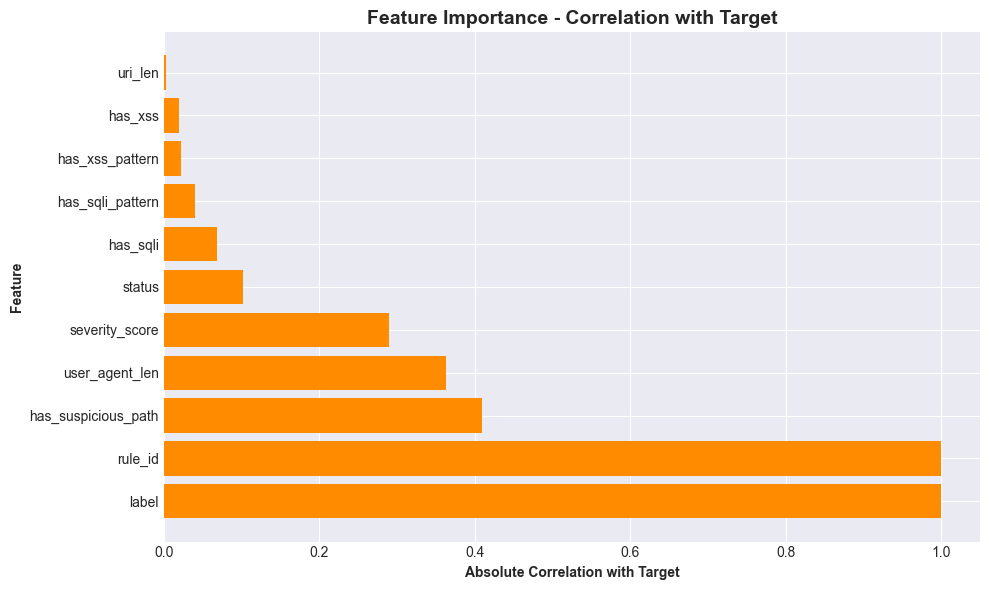

In [28]:
    # Method 3: Correlation with target
    print("\n" + "-" * 80)
    print("METHOD 3: Correlation with Target Variable")
    print("-" * 80)
    
    correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
    corr_df = pd.DataFrame({
        'Feature': correlation_with_target.index,
        'Correlation': correlation_with_target.values
    })
    print(corr_df)
    
    # Visualize correlation
    plt.figure(figsize=(10, 6))
    plt.barh(corr_df['Feature'], corr_df['Correlation'], color='darkorange')
    plt.xlabel('Absolute Correlation with Target', fontweight='bold')
    plt.ylabel('Feature', fontweight='bold')
    plt.title('Feature Importance - Correlation with Target', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


--------------------------------------------------------------------------------
METHOD 2: Random Forest Feature Importance (⏳ Processing...)
--------------------------------------------------------------------------------
✓ Random Forest training completed in 1.67 seconds
                Feature  Importance
8                 label    0.392184
7               rule_id    0.350921
4        user_agent_len    0.112952
1                status    0.094522
13  has_suspicious_path    0.024445
5               uri_len    0.014631
6        severity_score    0.009411
9              has_sqli    0.000669
11     has_sqli_pattern    0.000136
12      has_xss_pattern    0.000111
10              has_xss    0.000019
3          request_time    0.000000
2            bytes_sent    0.000000
0             timestamp    0.000000
14           rule_count    0.000000


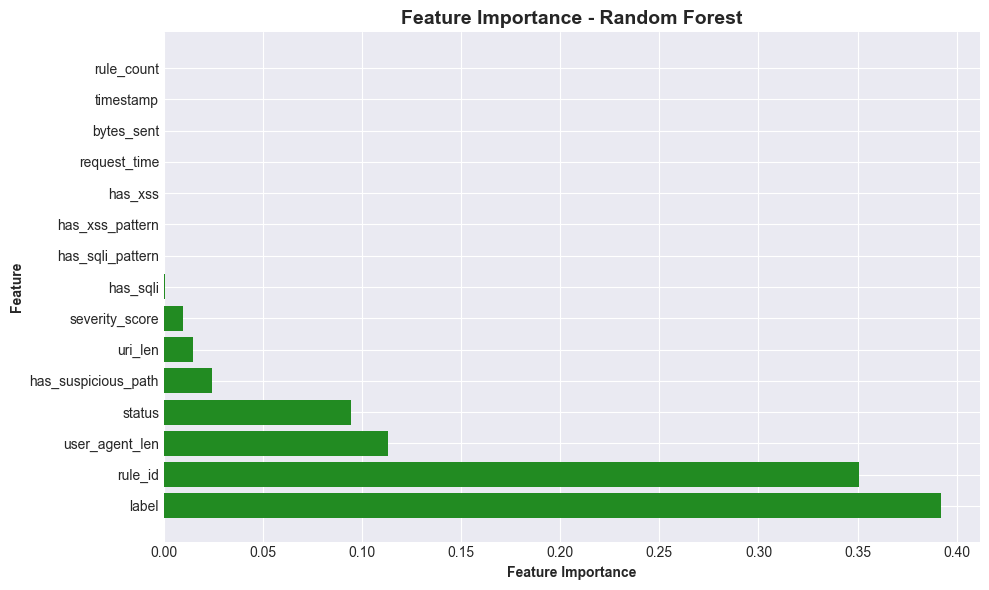

In [29]:
    # Method 2: Random Forest Feature Importance (ini yang lama)
    print("\n" + "-" * 80)
    print("METHOD 2: Random Forest Feature Importance (⏳ Processing...)")
    print("-" * 80)
    
    start_time = time.time()
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X, y)
    elapsed = time.time() - start_time
    
    rf_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(f"✓ Random Forest training completed in {elapsed:.2f} seconds")
    print(rf_importance_df)
    
    # Visualize RF importance
    plt.figure(figsize=(10, 6))
    plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='forestgreen')
    plt.xlabel('Feature Importance', fontweight='bold')
    plt.ylabel('Feature', fontweight='bold')
    plt.title('Feature Importance - Random Forest', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

FEATURE IMPORTANCE ANALYSIS

Features used for importance: 15

--------------------------------------------------------------------------------
METHOD 1: Mutual Information Score
--------------------------------------------------------------------------------
                Feature  MI Score
8                 label  0.647098
7               rule_id  0.643303
4        user_agent_len  0.513299
1                status  0.432697
5               uri_len  0.264572
13  has_suspicious_path  0.127059
6        severity_score  0.085124
9              has_sqli  0.003707
10              has_xss  0.002156
11     has_sqli_pattern  0.002128
3          request_time  0.001487
0             timestamp  0.000687
12      has_xss_pattern  0.000377
2            bytes_sent  0.000000
14           rule_count  0.000000


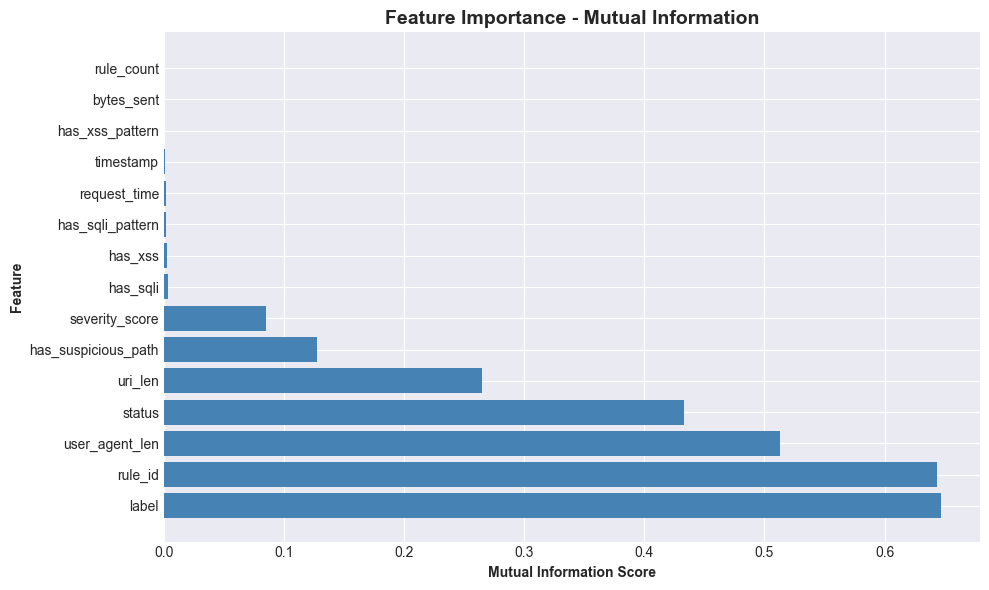

In [30]:
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Prepare data for feature importance
if 'label' in df.columns:
    # Select only numeric features for analysis
    X = df[numeric_cols]
    y = df['label']
    
    # Handle any remaining NaN values
    X = X.fillna(0)
    
    print(f"\nFeatures used for importance: {len(numeric_cols)}")
    
    # Method 1: Mutual Information
    print("\n" + "-" * 80)
    print("METHOD 1: Mutual Information Score")
    print("-" * 80)
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X.columns,
        'MI Score': mi_scores
    }).sort_values('MI Score', ascending=False)
    print(mi_df)
    
    # Visualize MI scores
    plt.figure(figsize=(10, 6))
    plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')
    plt.xlabel('Mutual Information Score', fontweight='bold')
    plt.ylabel('Feature', fontweight='bold')
    plt.title('Feature Importance - Mutual Information', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Feature Importance Analysis

⏱️ **Note:** This section uses Random Forest which may take 30-60 seconds to complete depending on dataset size.


TARGET VARIABLE (label) DISTRIBUTION

Value counts:
label
0    95144
1    47561
Name: count, dtype: int64

Percentage:
label
0    66.671805
1    33.328195
Name: proportion, dtype: float64


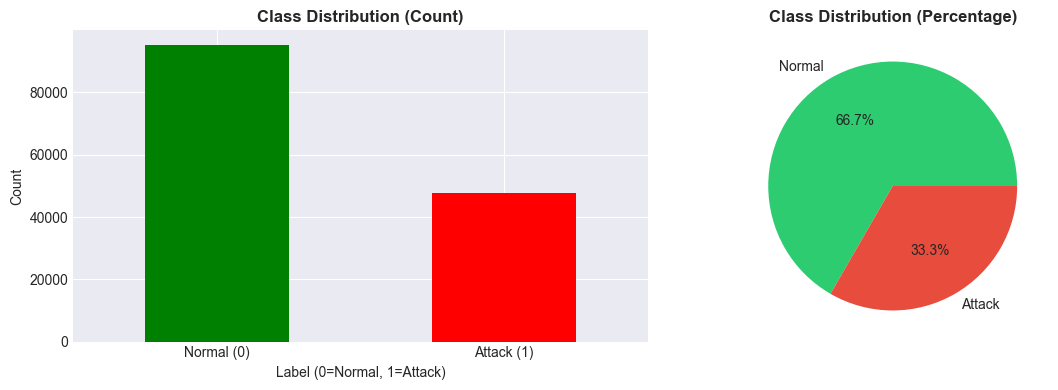

In [31]:
# Target variable distribution
if 'label' in df.columns:
    print("\n" + "=" * 80)
    print("TARGET VARIABLE (label) DISTRIBUTION")
    print("=" * 80)
    print("\nValue counts:")
    print(df['label'].value_counts().sort_index())
    print("\nPercentage:")
    print(df['label'].value_counts(normalize=True).sort_index() * 100)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot
    df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
    axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Label (0=Normal, 1=Attack)')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'], rotation=0)
    
    # Pie chart
    labels = ['Normal', 'Attack']
    colors = ['#2ecc71', '#e74c3c']
    df['label'].value_counts().plot(kind='pie', ax=axes[1], labels=labels, colors=colors, autopct='%1.1f%%')
    axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()

In [32]:
print("\n" + "-" * 80)
print("CATEGORICAL FEATURES DISTRIBUTION")
print("-" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


--------------------------------------------------------------------------------
CATEGORICAL FEATURES DISTRIBUTION
--------------------------------------------------------------------------------

source_ip:
source_ip
0.0.0.0    142705
Name: count, dtype: int64

method:
method
GET         127567
POST         14484
HEAD           499
PROPFIND        71
PUT             47
OPTIONS         12
DELETE          12
CONNECT          6
PATCH            6
ROAJ             1
Name: count, dtype: int64

uri:
uri
/robots.txt      17489
/xmlrpc.php       9966
/                 8254
/.env             4517
/.git/config      3917
/api/.env         1420
/.git/HEAD        1231
/d_43826a23        930
/admin/.env        918
/backend/.env      906
Name: count, dtype: int64

user_agent:
user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36                                                                                           36269
Moz

In [33]:
print("=" * 80)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 80)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nNumeric columns: {len(numeric_cols)}")
print(df[numeric_cols].describe().T)

STATISTICAL SUMMARY - NUMERICAL FEATURES

Numeric columns: 15
                        count           mean            std       min  \
timestamp                 0.0            NaN            NaN       NaN   
status               142705.0     395.061154      48.260993     301.0   
bytes_sent           142705.0       0.000000       0.000000       0.0   
request_time         142705.0       0.000000       0.000000       0.0   
user_agent_len       142705.0      88.409628      42.775497       0.0   
uri_len              142705.0      22.827567      84.764371       1.0   
severity_score       142705.0       3.633867       0.894410       0.0   
rule_id              142705.0  765627.605452  227179.069076  200002.0   
label                142705.0       0.333282       0.471388       0.0   
has_sqli             142705.0       0.009138       0.095154       0.0   
has_xss              142705.0       0.000799       0.028253       0.0   
has_sqli_pattern     142705.0       0.003279       0.057173   

## 4. Statistical Summary and Distribution Analysis

In [34]:
print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

# Missing values
print("\n" + "-" * 80)
print("MISSING VALUES")
print("-" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_df) == 0:
    print("✓ No missing values detected!")
else:
    print(missing_df.to_string(index=False))

# Duplicates
print("\n" + "-" * 80)
print("DUPLICATE ROWS")
print("-" * 80)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
print(f"Duplicate percentage: {(duplicates/len(df)*100):.2f}%")

# Data consistency
print("\n" + "-" * 80)
print("DATA COMPLETENESS")
print("-" * 80)
total_cells = df.shape[0] * df.shape[1]
null_cells = df.isnull().sum().sum()
completeness = ((total_cells - null_cells) / total_cells) * 100
print(f"Total cells: {total_cells:,}")
print(f"Null cells: {null_cells:,}")
print(f"Completeness: {completeness:.2f}%")

DATA QUALITY ASSESSMENT

--------------------------------------------------------------------------------
MISSING VALUES
--------------------------------------------------------------------------------
      Column  Missing Count  Missing %
   timestamp         142705 100.000000
matched_data          44368  31.090712
  user_agent          13723   9.616341
    severity             21   0.014716
         msg              3   0.002102

--------------------------------------------------------------------------------
DUPLICATE ROWS
--------------------------------------------------------------------------------
Total duplicate rows: 110502
Duplicate percentage: 77.43%

--------------------------------------------------------------------------------
DATA COMPLETENESS
--------------------------------------------------------------------------------
Total cells: 3,282,215
Null cells: 200,820
Completeness: 93.88%


## 3. Data Quality Assessment

In [35]:
print("\n" + "-" * 80)
print("DATA TYPES & COLUMNS LIST")
print("-" * 80)
print("\nData Types:")
print(df.dtypes)

print("\n" + "-" * 80)
print("COLUMN NAMES")
print("-" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


--------------------------------------------------------------------------------
DATA TYPES & COLUMNS LIST
--------------------------------------------------------------------------------

Data Types:
timestamp              float64
source_ip               object
method                  object
uri                     object
status                   int64
bytes_sent               int64
request_time           float64
user_agent              object
user_agent_len           int64
uri_len                  int64
severity                object
severity_score           int64
rule_id                  int64
matched_data            object
msg                     object
is_blocked                bool
label                    int64
has_sqli                 int64
has_xss                  int64
has_sqli_pattern         int64
has_xss_pattern          int64
has_suspicious_path      int64
rule_count               int64
dtype: object

----------------------------------------------------------------------

In [36]:
print("\n" + "-" * 80)
print("FIRST FEW ROWS")
print("-" * 80)
df.head(10)


--------------------------------------------------------------------------------
FIRST FEW ROWS
--------------------------------------------------------------------------------


,timestamp,source_ip,method,uri,status,bytes_sent,request_time,user_agent,user_agent_len,uri_len,severity,severity_score,rule_id,matched_data,msg,is_blocked,label,has_sqli,has_xss,has_sqli_pattern,has_xss_pattern,has_suspicious_path,rule_count
0,NaN,0.0.0.0,GET,/wp-includesSimplePiegzdecodes.php,404,0,0.0,NaN,0,34,CRITICAL,4,933150,gzdecode,PHP Injection Attack: High-Risk PHP Function N...,False,0,0,0,0,0,0,0
1,NaN,0.0.0.0,GET,/d_3b1ec613/d_bd205cb5/gzdecodes.php,404,0,0.0,NaN,0,36,CRITICAL,4,933150,gzdecode,PHP Injection Attack: High-Risk PHP Function N...,False,0,0,0,0,0,0,0
2,NaN,0.0.0.0,GET,/d_58b7df65/d_4853cf40/d_a08340a6/d_d668184e/d...,301,0,0.0,Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like...,139,55,WARNING,2,920210,NaN,Multiple/Conflicting Connection Header Data Fo...,False,0,0,0,0,0,0,0
3,NaN,0.0.0.0,GET,/.git/config,404,0,0.0,NaN,0,12,CRITICAL,4,930130,/.git/,Restricted File Access Attempt,False,0,0,0,0,0,0,0
4,NaN,0.0.0.0,GET,/d_9161f094/d_74f0f511/semmelrock-alkalmazaste...,301,0,0.0,Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like...,139,66,WARNING,2,920210,NaN,Multiple/Conflicting Connection Header Data Fo...,False,0,0,0,0,0,0,0
5,NaN,0.0.0.0,GET,/d_022219ab/d_7a506bb6/d_eac5f762/d_620f83a6,304,0,0.0,Mozilla/5.0 (Windows NT 10.0; Win64; x64; tren...,202,44,CRITICAL,4,920450,NaN,HTTP header is restricted by policy (/accept-c...,False,0,0,0,0,0,0,0
6,NaN,0.0.0.0,GET,/robots.txt,403,0,0.0,NaN,0,11,CRITICAL,4,444444,DotBot,BAD BOT - Detected and Blocked.,True,1,0,0,0,0,0,0
7,NaN,0.0.0.0,GET,/robots.txt,403,0,0.0,NaN,0,11,CRITICAL,4,444444,DotBot,BAD BOT - Detected and Blocked.,True,1,0,0,0,0,0,0
8,NaN,0.0.0.0,GET,/wp-config.php,301,0,0.0,NaN,0,14,CRITICAL,4,930130,wp-config.php,Restricted File Access Attempt,False,0,0,0,0,0,0,0
9,NaN,0.0.0.0,GET,/wp-config.php,301,0,0.0,NaN,0,14,CRITICAL,4,930130,wp-config.php,Restricted File Access Attempt,False,0,0,0,0,0,0,0


In [37]:
# Load dataset
data_path = '../data/dataset/modsec_raw_processed_updated.csv'
df = pd.read_csv(data_path)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

print("\n" + "-" * 80)
print("COLUMN INFORMATION")
print("-" * 80)
df.info()

DATASET OVERVIEW

Dataset Shape: (142705, 23)
Rows: 142,705, Columns: 23

--------------------------------------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142705 entries, 0 to 142704
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            0 non-null       float64
 1   source_ip            142705 non-null  object 
 2   method               142705 non-null  object 
 3   uri                  142705 non-null  object 
 4   status               142705 non-null  int64  
 5   bytes_sent           142705 non-null  int64  
 6   request_time         142705 non-null  float64
 7   user_agent           128982 non-null  object 
 8   user_agent_len       142705 non-null  int64  
 9   uri_len              142705 non-null  int64  
 10  severity         

## 2. Load and Inspect Dataset

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
import time
import warnings
import os

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Print settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Import Required Libraries

# Exploratory Data Analysis (EDA)
## OJS Real-Time Attack Detection Dataset

Comprehensive analysis of the ModSecurity dataset including data inspection, quality assessment, statistical analysis, and feature importance.